# NATRE Calculating Terms

This notebook is for taking individual profiles and calculating terms 2, 3, and 4 of the simplified tracer variance budget from Ferrari & Polzin (2005). I think I will just start by taking an example profile (in p and p_bar space) and attempting to calculate each term. 2 and 3 will be straightforward, 4 might be a little more interesting.

In [1]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.path import Path
import matplotlib.colors as colors
import cmocean.cm as cmo
import cartopy.crs as ccrs
import gsw
import mixsea as mx
from scipy.ndimage import gaussian_filter1d

In [34]:
import os
os.chdir('/home/amf2288/argo-intern/funcs')
import filt_funcs as ff

## Load datasets, select NATRE region

In [2]:
if 'OUT' not in globals():
    OUT = '/swot/SUM05/amf2288/'

ds_p = xr.open_zarr(OUT + 'complete_ds_p.zarr', consolidated=True,
                    chunks={'PROFILE': 2500})
ds_r = xr.open_zarr(OUT + 'complete_ds_r.zarr', consolidated=True,
                    chunks={'PROFILE': 2500})
ds_pbar = xr.open_zarr(OUT + 'complete_ds_pbar.zarr', consolidated=True,
                       chunks={'PROFILE': 2500})

# The stored PROFILE ids are not unique, which breaks alignment-based operations.
ds_p, ds_r, ds_pbar = [
    dataset.assign_coords(PROFILE=np.arange(dataset.sizes['PROFILE']))
    for dataset in (ds_p, ds_r, ds_pbar)
]

for name, dataset in [('ds_p', ds_p), ('ds_r', ds_r), ('ds_pbar', ds_pbar)]:
    print(f'{name}: {dict(dataset.sizes)}')

/home/amf2288/miniconda3/envs/Argo_Feb_25/lib/python3.11/site-packages/xarray/backends/plugins.py:80: RuntimeWarning: Engine 'erddapy' loading failed:
cannot import name 'T_PathFileOrDataStore' from 'xarray.backends.common' (/home/amf2288/miniconda3/envs/Argo_Feb_25/lib/python3.11/site-packages/xarray/backends/common.py)
  warnings.warn(f"Engine {name!r} loading failed:\n{ex}", RuntimeWarning)


/home/amf2288/miniconda3/envs/Argo_Feb_25/lib/python3.11/site-packages/xarray/backends/plugins.py:80: RuntimeWarning: Engine 'erddapy' loading failed:
cannot import name 'T_PathFileOrDataStore' from 'xarray.backends.common' (/home/amf2288/miniconda3/envs/Argo_Feb_25/lib/python3.11/site-packages/xarray/backends/common.py)
  warnings.warn(f"Engine {name!r} loading failed:\n{ex}", RuntimeWarning)


ds_p: {'PROFILE': 2550896, 'PRESSURE': 1001}
ds_r: {'PROFILE': 2550896, 'DENSITY': 6000}
ds_pbar: {'PROFILE': 2550896, 'PRESSURE_mean': 1001}


In [3]:
# Keep only profiles whose non-NaN sample rates are all strictly below 5 m.
max_sample_rate = ds_p.sample_rate.max(dim='PRESSURE', skipna=True)
keep = (max_sample_rate < 5).fillna(False).values

n_total = ds_p.sizes['PROFILE']
n_keep = int(keep.sum())
if ds_pbar.sizes['PROFILE'] != n_total:
    raise ValueError('ds_p and ds_pbar must have matching PROFILE dimensions')
print(f'Keeping {n_keep} of {n_total} profiles with sample_rate < 5 m')

ds_p = ds_p.isel(PROFILE=np.flatnonzero(keep))
ds_pbar = ds_pbar.isel(PROFILE=np.flatnonzero(keep))

/home/amf2288/miniconda3/envs/Argo_Feb_25/lib/python3.11/site-packages/dask/array/reductions.py:327: RuntimeWarning: All-NaN slice encountered
  return np.nanmax(x_chunk, axis=axis, keepdims=keepdims)


/home/amf2288/miniconda3/envs/Argo_Feb_25/lib/python3.11/site-packages/dask/array/reductions.py:327: RuntimeWarning: All-NaN slice encountered
  return np.nanmax(x_chunk, axis=axis, keepdims=keepdims)


Keeping 766262 of 2550896 profiles with sample_rate < 5 m


In [4]:
def natre_mask(ds):
    return (
        (ds.LAT >= 20) & (ds.LAT <= 31) &
        (ds.LON >= -38) & (ds.LON <= -20) &
        (ds.TIME >= np.datetime64('2014-01-01')) &
        (ds.TIME <  np.datetime64('2025-01-01'))
    ).compute()

# ds_pbar and co_pbar are different profile collections, so each needs a mask
# from its own coords; sharing one makes xarray align on PROFILE label instead.

NATRE_p    = ds_p.where(natre_mask(ds_p), drop=True)
NATRE_pbar = ds_pbar.where(natre_mask(ds_pbar), drop=True)

print(f'{NATRE_p.sizes["PROFILE"]} ds_p profiles, '
      f'{NATRE_pbar.sizes["PROFILE"]} ds_pbar profiles in NATRE box')

2693 ds_p profiles, 2693 ds_pbar profiles in NATRE box


In [31]:
NATRE_p = NATRE_p.drop_vars(['CT_mean','SA_mean','SPICE_mean'])

In [32]:
np.nanmax(NATRE_p.sample_rate.values)

4.9942937

## Construct variance budget

### Calculate terms 2, 3, 4 on `ds_p`

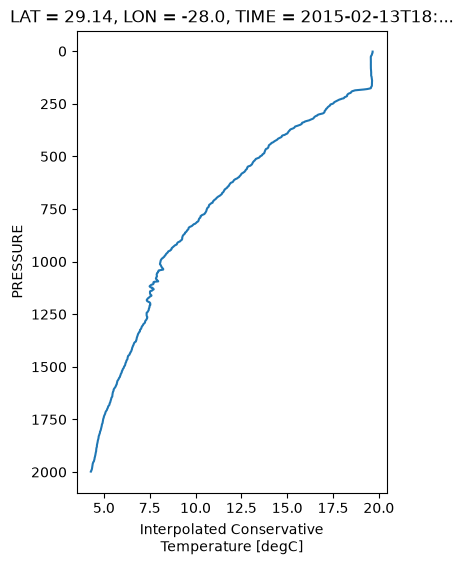

In [33]:
prof = NATRE_p.isel(PROFILE=51)

plt.figure(figsize=(4,6))
prof.CT.plot(y='PRESSURE')
plt.gca().invert_yaxis()

In [ ]:
TEMP = NATRE_p.TEMP.values.T
PSAL = NATRE_p.PSAL.values.T
Z    = NATRE_p.PRESSURE.values
LON  = NATRE_p.LON.values
LAT  = NATRE_p.LAT.values

In [18]:
print(f"Finescale")
# Center points of depth windows. Windows are half overlapping, i.e.
# their size (200m) is double the spacing here (100m).
window_size = 200
min_size = 10.
dZ = window_size // 4
print("window size {} m, window spacing {} m".format(window_size, dZ))
depth_bin = np.arange(dZ, 2000, dZ)
# Wavenumber vector. Starts at wavenumber corresponding to a 200m
# wavelength.
m = np.arange(2 * np.pi / window_size, 2 * np.pi / min_size, 2 * np.pi / window_size)
# Wavenumber indices for integration. Shear is integrated from 300m to
# 100m scales. Strain is integrated from 150m to 30m.
m_include_sh = list(range(3))
m_include_st = list(range(1, 12))
N_PROF = len(NATRE_p.PROFILE)

eps_st = np.full( (depth_bin.size, N_PROF), np.nan)
Krho_st = np.full( (depth_bin.size, N_PROF), np.nan)
depth_st = np.full( (depth_bin.size, N_PROF), np.nan)
for i in range(N_PROF):
    if np.sum(np.isfinite(TEMP[:,i]+PSAL[:,i]))<100:
        continue
    try:
        eps_shst, krho_shst, diag = mx.shearstrain.nan_shearstrain(
            Z,
            TEMP[:,i],
            PSAL[:,i],
            LON[i],
            LAT[i],
            TEMP[:,i]*0.,
            TEMP[:,i]*0.,
            Z,
            m=m,
            depth_bin=depth_bin,
            window_size=window_size,
            m_include_sh=m_include_sh,
            m_include_st=m_include_st,
            ladcp_is_shear=True,
            smooth="AL",
            return_diagnostics=True,
        )
    except ValueError as e:
        print(f"Skipped profile at index {i} due to error: {e}")
        continue

    z0 = diag['depth_bin']
    for j in range(z0.size):
        jj = np.where(depth_bin == z0[j])[0]
        if jj.size == 0:
            continue
        eps_st[jj[0],i] =  diag['eps_st'][j]
        Krho_st[jj[0],i] = diag['krho_st'][j]

Finescale
window size 200 m, window spacing 50 m


Finescale
window size 200 m, window spacing 50 m


/home/amf2288/miniconda3/envs/Argo_Feb_25/lib/python3.11/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,


Finescale
window size 200 m, window spacing 50 m


/home/amf2288/miniconda3/envs/Argo_Feb_25/lib/python3.11/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,


Skipped profile at index 2396 due to error: zero-size array to reduction operation maximum which has no identity


In [19]:
NATRE_Krho = xr.Dataset(
    data_vars=dict(
        eps   = (("PRESSURE", "PROFILE"), eps_st),
        Krho  = (("PRESSURE", "PROFILE"), Krho_st),
        depth = (("PRESSURE", "PROFILE"), depth_st),
    ),
    coords=dict(
        PRESSURE = depth_bin,
        PROFILE  = NATRE_p.PROFILE.values,
        LAT      = ("PROFILE", NATRE_p.LAT.values),
        LON      = ("PROFILE", NATRE_p.LON.values),
        TIME     = ("PROFILE", NATRE_p.TIME.values),
    ),
)

In [51]:
NATRE_Krho = NATRE_Krho.interp(PRESSURE=NATRE_p.PRESSURE)

In [53]:
lfilt = 100

NATRE_p['CTm']    = ff.ds_filt_nan(NATRE_p, lfilt, variable='CT', dim1='PROFILE', dim2='PRESSURE')
NATRE_p['CTe']    = NATRE_p.CT - NATRE_p.CTm
print('CT complete')
NATRE_p['SAm']    = ff.ds_filt_nan(NATRE_p, lfilt, variable='SA', dim1='PROFILE', dim2='PRESSURE')
NATRE_p['SAe']    = NATRE_p.SA - NATRE_p.SAm
print('SA complete')
NATRE_p['SPICEm'] = ff.ds_filt_nan(NATRE_p, lfilt, variable='SPICE', dim1='PROFILE', dim2='PRESSURE')
NATRE_p['SPICEe'] = NATRE_p.SPICE - NATRE_p.SPICEm
print('SPICE complete')

CT complete
SA complete
SPICE complete


In [76]:
dCTm_dz2 = (NATRE_p.CTm.differentiate('PRESSURE'))**2
dCTe_dz2 = ff.ds_filt_nan((NATRE_p.CTe.differentiate('PRESSURE')**2).to_dataset(name='var'), lfilt, variable='var', dim1='PROFILE', dim2='PRESSURE')
dCT_dz2  = ff.ds_filt_nan((NATRE_p.CT.differentiate('PRESSURE')**2).to_dataset(name='var'), lfilt, variable='var', dim1='PROFILE', dim2='PRESSURE')
print('CT complete')
dSAm_dz2 = (NATRE_p.SAm.differentiate('PRESSURE'))**2
dSAe_dz2 = ff.ds_filt_nan((NATRE_p.SAe.differentiate('PRESSURE')**2).to_dataset(name='var'), lfilt, variable='var', dim1='PROFILE', dim2='PRESSURE')
dSA_dz2  = ff.ds_filt_nan((NATRE_p.SA.differentiate('PRESSURE')**2).to_dataset(name='var'), lfilt, variable='var', dim1='PROFILE', dim2='PRESSURE')
print('SA complete')
dSPICEm_dz2 = (NATRE_p.SPICEm.differentiate('PRESSURE'))**2
dSPICEe_dz2 = ff.ds_filt_nan((NATRE_p.SPICEe.differentiate('PRESSURE')**2).to_dataset(name='var'), lfilt, variable='var', dim1='PROFILE', dim2='PRESSURE')
dSPICE_dz2  = ff.ds_filt_nan((NATRE_p.SPICE.differentiate('PRESSURE')**2).to_dataset(name='var'), lfilt, variable='var', dim1='PROFILE', dim2='PRESSURE')
print('SPICE complete')

CT complete
SA complete
SPICE complete


In [77]:
CT2 = NATRE_Krho.Krho * (dCTe_dz2)
CT3 = NATRE_Krho.Krho * (dCTm_dz2)
CT4 = NATRE_Krho.Krho * (dCT_dz2)
print('CT complete')
SA2 = NATRE_Krho.Krho * (dSAe_dz2)
SA3 = NATRE_Krho.Krho * (dSAm_dz2)
SA4 = NATRE_Krho.Krho * (dSA_dz2)
print('SA complete')
SPICE2 = NATRE_Krho.Krho * (dSPICEe_dz2)
SPICE3 = NATRE_Krho.Krho * (dSPICEm_dz2)
SPICE4 = NATRE_Krho.Krho * (dSPICE_dz2)
print('SPICE complete')

CT complete
SA complete
SPICE complete


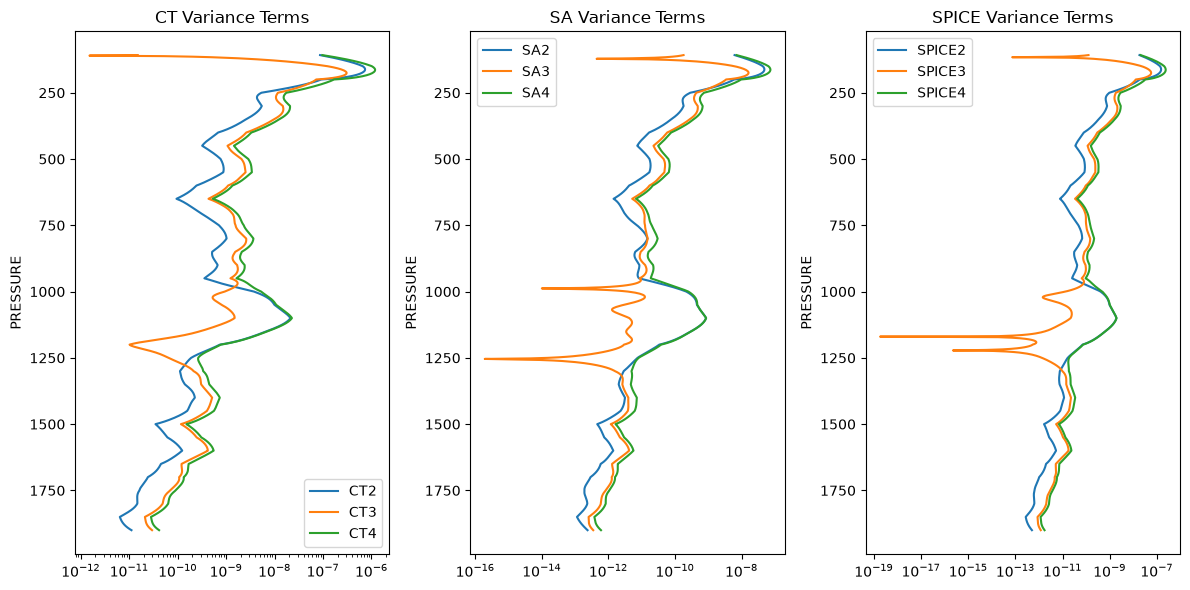

In [78]:
plt.figure(figsize=(12,6))

plt.subplot(131)
CT2.isel(PROFILE=51).plot(y='PRESSURE', label='CT2')
CT3.isel(PROFILE=51).plot(y='PRESSURE', label='CT3')
CT4.isel(PROFILE=51).plot(y='PRESSURE', label='CT4')
plt.gca().invert_yaxis()
plt.xscale('log')
plt.legend()
plt.title('CT Variance Terms')

plt.subplot(132)
SA2.isel(PROFILE=51).plot(y='PRESSURE', label='SA2')
SA3.isel(PROFILE=51).plot(y='PRESSURE', label='SA3')
SA4.isel(PROFILE=51).plot(y='PRESSURE', label='SA4')
plt.gca().invert_yaxis()
plt.xscale('log')
plt.legend()
plt.title('SA Variance Terms')


plt.subplot(133)
SPICE2.isel(PROFILE=51).plot(y='PRESSURE', label='SPICE2')
SPICE3.isel(PROFILE=51).plot(y='PRESSURE', label='SPICE3')
SPICE4.isel(PROFILE=51).plot(y='PRESSURE', label='SPICE4')
plt.gca().invert_yaxis()
plt.xscale('log')
plt.legend()
plt.title('SPICE Variance Terms')

plt.tight_layout()

### Calculate terms 2, 3, 4 on `ds_pbar`